# Importar librerías

In [2]:
# Librerías para cargar y manipular datos
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import ks_2samp

# Librerías para visualización
from matplotlib import pyplot as plt
import seaborn as sns

# Cargar recursos

In [13]:
# Directorio donde se encuentran los resultados de las ejecuciones de la fase 1 del experimento
# de autoencoders por dispositivo
OUTPUT_FOLDER = Path("../../outputs/runs/nbaiot_autoencoder_per_device_stage_1/devices")

# Identificador del dispositivo a analizar
DEVICES_IDS = [f"device_{i}" for i in range(1, 10)]

# Identificador de las configuraciones de los modelos a analizar
MODEL_IDS = [
    "model_1_base_mse",
    "model_2_base_mae",
    "model_3_compact_mse",
    "model_4_compact_regularized_mse",
    "model_5_compact_regularized_mae",
]

In [19]:
# Cargar en un mismo dataframe los historiales de entrenamiento de los modelos entrenados para cada dispositivo
histories = []
for device_id in DEVICES_IDS:
    for model_id in MODEL_IDS:
        history_path = OUTPUT_FOLDER / device_id / model_id / "history.csv"

        history_df = pd.read_csv(history_path)

        history_df["device"] = device_id
        history_df["model_id"] = model_id

        histories.append(history_df)

histories_df = pd.concat(histories, ignore_index=True)

histories_df = histories_df[
    ["device", "model_id", "epoch", "loss", "val_loss"]
]

# Analizar procesos de entrenamiento

En este primer *stage* de la experimentación se analiza el comportamiento del proceso de entrenamiento de las distintas configuraciones de autoencoder propuestas. El objetivo no es seleccionar todavía el modelo definitivo, sino estudiar cómo influyen diferentes decisiones de diseño sobre la capacidad del modelo para reconstruir el tráfico benigno.

Para ello, el análisis se centra en la evolución de las curvas de entrenamiento y validación obtenidas durante el aprendizaje. A partir de estas comparativas se identificarán las configuraciones más prometedoras, permitiendo acotar el espacio de búsqueda que se empleará posteriormente durante la optimización de hiperparámetros mediante Optuna.

In [46]:
def plot_aggregated_metric_comparison(
    aggregated_df: pd.DataFrame,
    model_labels: dict[str, str],
    metric_mean_col: str,
    metric_std_col: str,
    ylabel: str,
    title: str,
) -> None:
    plt.figure(figsize=(10, 6))

    for model_id, model_label in model_labels.items():
        model_df = aggregated_df[aggregated_df["model_id"] == model_id]

        epochs = model_df["epoch"].to_numpy()
        mean_values = model_df[metric_mean_col].to_numpy()
        std_values = model_df[metric_std_col].fillna(0).to_numpy()

        plt.plot(
            epochs,
            mean_values,
            label=model_label,
            linewidth=2,
        )

        plt.fill_between(
            epochs,
            mean_values - std_values,
            mean_values + std_values,
            alpha=0.15,
        )

    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(ylabel)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 1. Influencia de la función de pérdida

En esta primera comparativa se analiza el efecto de la función de pérdida utilizada durante el entrenamiento del autoencoder. Para ello se comparan dos modelos con la misma arquitectura y sin regularización, variando únicamente la función de error: MSE en el Modelo 1 y MAE en el Modelo 2.

El objetivo es comprobar si el cambio de función de pérdida modifica de forma relevante la dinámica de aprendizaje del modelo. Para ello se estudia la evolución media de `loss` y `val_loss` a lo largo de las épocas, agregando los resultados de los nueve dispositivos. Esta representación permite observar tanto la capacidad de ajuste sobre el conjunto de entrenamiento como la capacidad de generalización sobre validación benigna.

In [45]:
LOSS_COMPARISON_MODELS = {
    "model_1_base_mse": "Modelo 1 - Base + MSE",
    "model_2_base_mae": "Modelo 2 - Base + MAE",
}


def aggregate_training_curves(
    histories_df: pd.DataFrame,
    model_ids: list[str],
) -> pd.DataFrame:
    comparison_df = histories_df[
        histories_df["model_id"].isin(model_ids)
    ].copy()

    aggregated_df = (
        comparison_df
        .groupby(["model_id", "epoch"], as_index=False)
        .agg(
            loss_mean=("loss", "mean"),
            loss_std=("loss", "std"),
            val_loss_mean=("val_loss", "mean"),
            val_loss_std=("val_loss", "std"),
            n_devices=("device", "nunique"),
        )
    )

    return aggregated_df


loss_comparison_df = aggregate_training_curves(
    histories_df=histories_df,
    model_ids=list(LOSS_COMPARISON_MODELS.keys()),
)

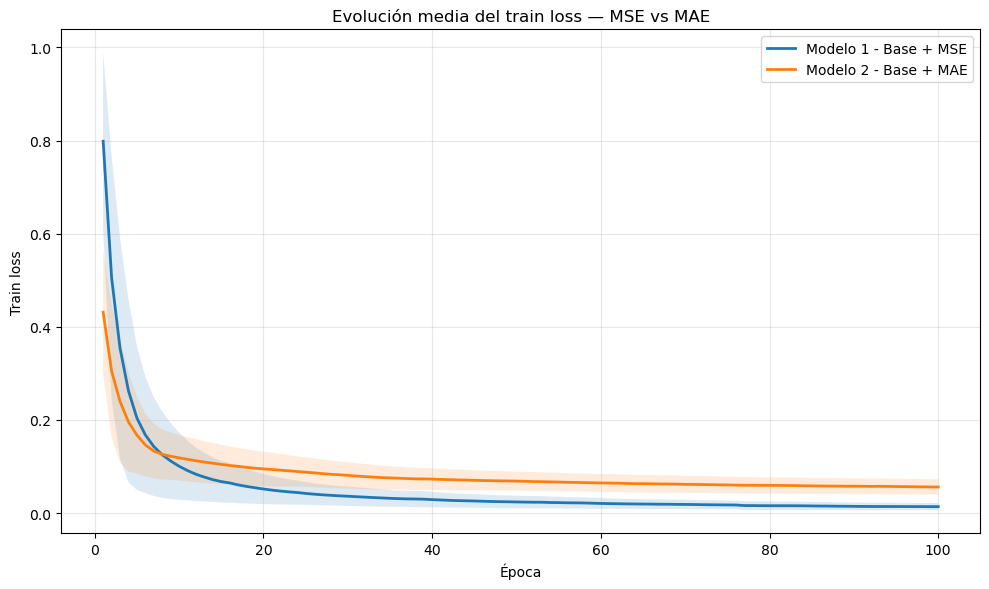

In [24]:
plot_aggregated_metric_comparison(
    aggregated_df=loss_comparison_df,
    model_labels=LOSS_COMPARISON_MODELS,
    metric_mean_col="loss_mean",
    metric_std_col="loss_std",
    ylabel="Train loss",
    title="Evolución media del train loss — MSE vs MAE",
)

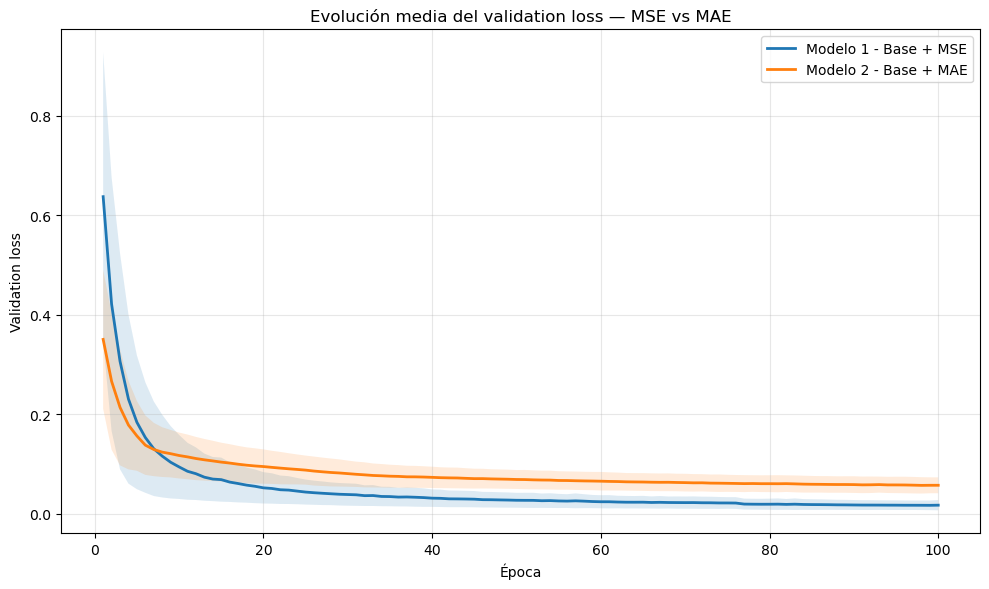

In [25]:
plot_aggregated_metric_comparison(
    aggregated_df=loss_comparison_df,
    model_labels=LOSS_COMPARISON_MODELS,
    metric_mean_col="val_loss_mean",
    metric_std_col="val_loss_std",
    ylabel="Validation loss",
    title="Evolución media del validation loss — MSE vs MAE",
)

Las curvas de entrenamiento muestran un comportamiento muy consistente entre ambos modelos. En primer lugar, se observa que el **Modelo 1 (MSE)** converge más rápidamente durante las primeras épocas y continúa reduciendo tanto la pérdida de entrenamiento como la de validación de forma sostenida hasta alcanzar valores claramente inferiores a los obtenidos por el **Modelo 2 (MAE)**. Este comportamiento se mantiene de forma consistente a lo largo de los nueve dispositivos, lo que sugiere que el uso de MSE resulta más adecuado para optimizar la reconstrucción del tráfico benigno en este problema.

Por otra parte, las curvas de `loss` y `val_loss` presentan una evolución muy similar en ambos modelos, sin apreciarse indicios de sobreajuste durante el entrenamiento. Dado que tanto el conjunto de entrenamiento como el de validación están formados exclusivamente por tráfico benigno procedente del mismo dispositivo, este comportamiento era esperable y confirma que el modelo mantiene una buena capacidad de generalización sobre datos no vistos pertenecientes a la misma distribución.

También resulta interesante observar que la variabilidad entre dispositivos es considerable durante las primeras épocas, especialmente en el modelo entrenado con MSE. Sin embargo, dicha variabilidad disminuye progresivamente conforme avanza el entrenamiento, indicando que los distintos dispositivos convergen hacia un comportamiento relativamente homogéneo independientemente de sus características particulares.

En conjunto, estos resultados indican que **la función de pérdida MSE proporciona un proceso de entrenamiento más eficiente y una mejor capacidad de reconstrucción del tráfico benigno que MAE**, por lo que constituye la opción más prometedora para continuar la experimentación en el siguiente *stage*.

## 2. Influencia de la capacidad de codificación del autoencoder

En esta segunda comparativa se analiza el efecto de reducir la capacidad de representación del autoencoder. Para ello se comparan dos modelos entrenados con la misma función de pérdida (MSE) y sin técnicas de regularización, diferenciándose únicamente en la capacidad de su espacio latente y, en consecuencia, en el número de neuronas de las capas ocultas.

El objetivo es estudiar cómo afecta una arquitectura más compacta al proceso de aprendizaje. Una reducción excesiva de la capacidad de codificación puede dificultar la reconstrucción del tráfico benigno, mientras que una capacidad demasiado elevada podría resultar innecesaria e incrementar el coste computacional del modelo. Por ello, se analiza la evolución media de `loss` y `val_loss` a lo largo del entrenamiento para determinar si una arquitectura más compacta es capaz de mantener un comportamiento similar al del modelo base.

In [44]:
CAPACITY_COMPARISON_MODELS = {
    "model_1_base_mse": "Modelo 1 - Arquitectura base",
    "model_3_compact_mse": "Modelo 3 - Arquitectura compacta",
}

capacity_comparison_df = aggregate_training_curves(
    histories_df=histories_df,
    model_ids=list(CAPACITY_COMPARISON_MODELS.keys()),
)

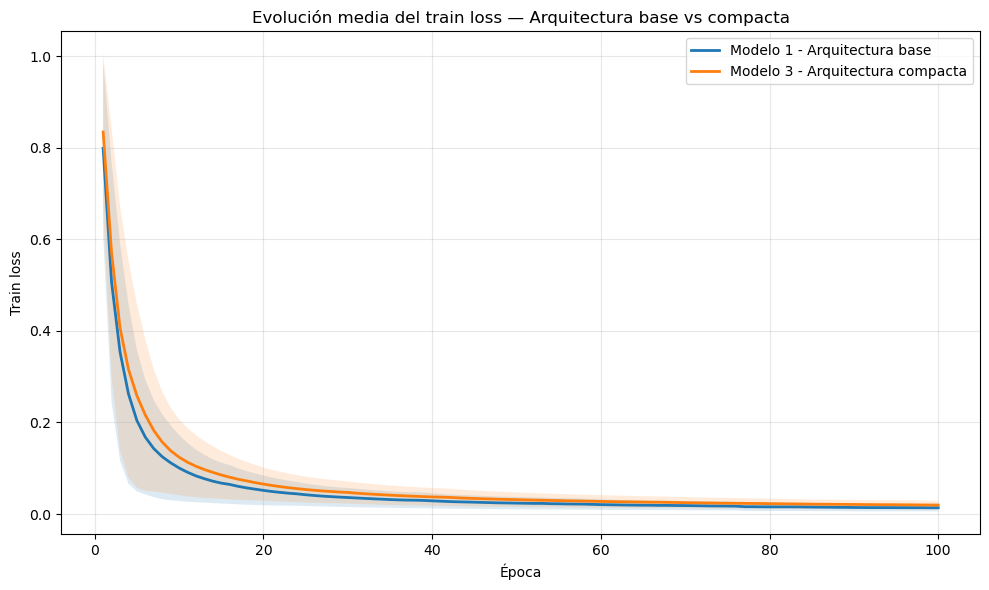

In [28]:
plot_aggregated_metric_comparison(
    aggregated_df=capacity_comparison_df,
    model_labels=CAPACITY_COMPARISON_MODELS,
    metric_mean_col="loss_mean",
    metric_std_col="loss_std",
    ylabel="Train loss",
    title="Evolución media del train loss — Arquitectura base vs compacta",
)

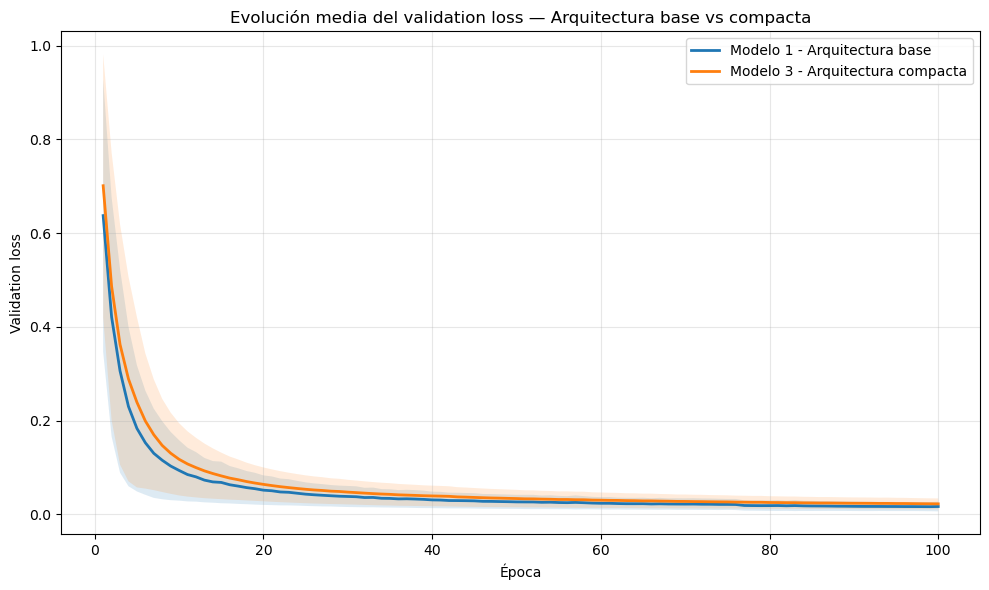

In [29]:
plot_aggregated_metric_comparison(
    aggregated_df=capacity_comparison_df,
    model_labels=CAPACITY_COMPARISON_MODELS,
    metric_mean_col="val_loss_mean",
    metric_std_col="val_loss_std",
    ylabel="Validation loss",
    title="Evolución media del validation loss — Arquitectura base vs compacta",
)

En esta comparativa se observa que ambos modelos presentan un comportamiento muy similar tanto durante el entrenamiento como en la validación. Las curvas de `loss` y `val_loss` evolucionan prácticamente de forma paralela a lo largo de las 100 épocas, indicando que la reducción de la capacidad de codificación no altera significativamente la dinámica de aprendizaje del autoencoder.

El **Modelo 1** alcanza de forma consistente valores de pérdida ligeramente inferiores a los del **Modelo 3**, tanto en entrenamiento como en validación. No obstante, estas diferencias son reducidas y se mantienen estables durante todo el proceso de aprendizaje, por lo que no parecen justificar, por sí solas, el incremento de complejidad del modelo.

Desde el punto de vista computacional, la diferencia entre ambas arquitecturas resulta considerable. Mientras que el Modelo 1 dispone de **36 549 parámetros entrenables**, el Modelo 3 reduce esta cifra hasta **20 163 parámetros**, lo que supone una disminución aproximada del **45 %** en el número de parámetros del modelo. De forma análoga, el número de parámetros asociados al optimizador pasa de **73 100** a **40 328**, reduciendo también el consumo de memoria durante el entrenamiento.

En conjunto, estos resultados sugieren que una arquitectura más compacta es capaz de mantener una capacidad de reconstrucción muy similar a la del modelo base, reduciendo de forma significativa la complejidad del modelo. Por ello, la arquitectura compacta se considera una alternativa especialmente interesante sobre la que centrar la optimización de hiperparámetros en el siguiente *stage* de la experimentación.

## 3. Influencia de la regularización

En esta última comparativa se analiza el efecto de incorporar distintas estrategias de regularización al proceso de entrenamiento del autoencoder. Para ello se compara el Modelo 3, basado en una arquitectura compacta, con el Modelo 4, que mantiene una capacidad de codificación similar pero incorpora un conjunto de modificaciones orientadas a mejorar la estabilidad y la capacidad de generalización del modelo durante el entrenamiento.

El objetivo es estudiar si estas estrategias permiten obtener un proceso de aprendizaje más robusto y una mejor capacidad de reconstrucción del tráfico benigno. Para ello se analiza nuevamente la evolución media de `loss` y `val_loss` a lo largo del entrenamiento, agregando los resultados obtenidos en los nueve dispositivos.

In [43]:
REGULARIZATION_COMPARISON_MODELS = {
    "model_3_compact_mse": "Modelo 3 - Arquitectura compacta",
    "model_4_compact_regularized_mse": "Modelo 4 - Arquitectura regularizada",
}

regularization_comparison_df = aggregate_training_curves(
    histories_df=histories_df,
    model_ids=list(REGULARIZATION_COMPARISON_MODELS.keys()),
)

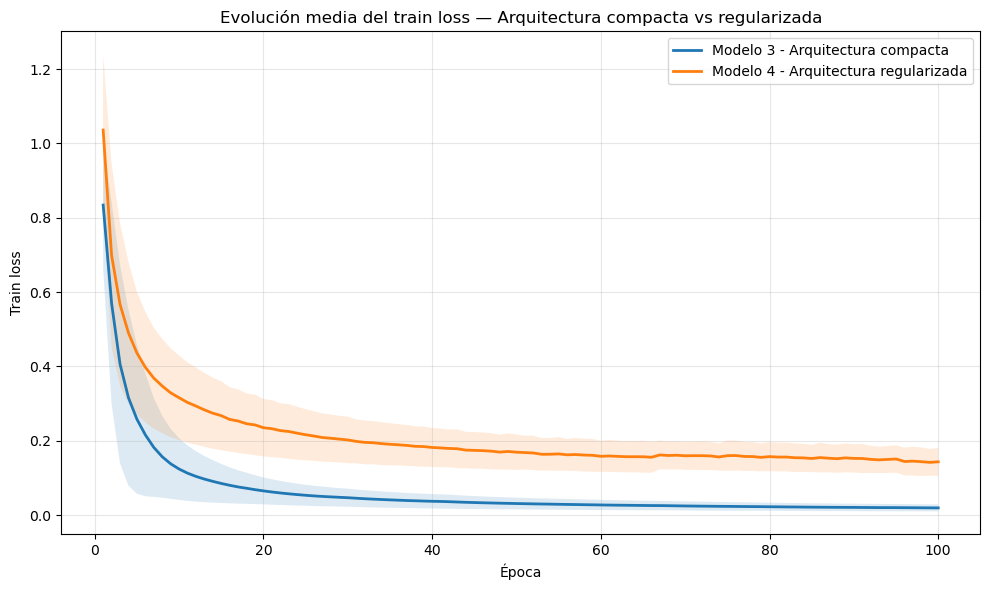

In [36]:
plot_aggregated_metric_comparison(
    aggregated_df=regularization_comparison_df,
    model_labels=REGULARIZATION_COMPARISON_MODELS,
    metric_mean_col="loss_mean",
    metric_std_col="loss_std",
    ylabel="Train loss",
    title="Evolución media del train loss — Arquitectura compacta vs regularizada",
)

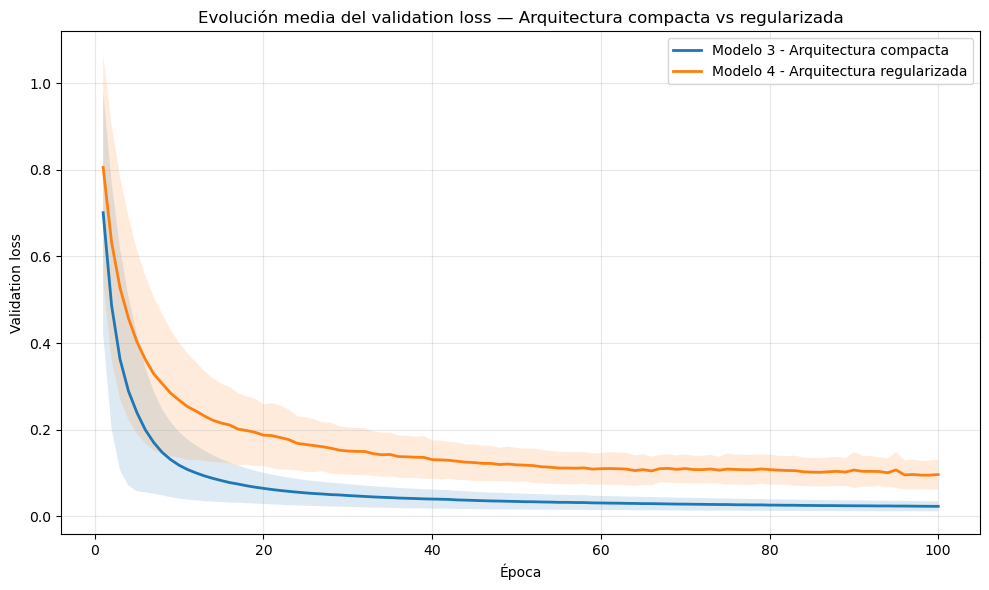

In [37]:
plot_aggregated_metric_comparison(
    aggregated_df=regularization_comparison_df,
    model_labels=REGULARIZATION_COMPARISON_MODELS,
    metric_mean_col="val_loss_mean",
    metric_std_col="val_loss_std",
    ylabel="Validation loss",
    title="Evolución media del validation loss — Arquitectura compacta vs regularizada",
)

Los resultados obtenidos muestran una diferencia clara entre ambas configuraciones. A diferencia de las comparativas anteriores, donde las diferencias observadas eran relativamente reducidas, en este caso la incorporación de técnicas de regularización produce un deterioro significativo tanto del proceso de entrenamiento como de la capacidad de reconstrucción sobre el conjunto de validación.

En primer lugar, se observa que el **Modelo 4** mantiene valores de `loss` considerablemente superiores a los del **Modelo 3** durante todo el entrenamiento. Aunque ambas configuraciones presentan una evolución descendente similar, la arquitectura regularizada converge mucho más lentamente y finaliza con una pérdida notablemente mayor. Este comportamiento indica que las restricciones introducidas reducen la capacidad del autoencoder para aprender una representación adecuada del tráfico benigno.

Este efecto también se refleja en las curvas de `val_loss`, donde el Modelo 4 obtiene sistemáticamente pérdidas superiores a las del Modelo 3. Además, la diferencia entre ambas configuraciones se mantiene prácticamente constante a lo largo de las épocas, lo que sugiere que el modelo regularizado no continúa acercándose al rendimiento de la arquitectura compacta conforme avanza el entrenamiento. De hecho, seis de los nueve modelos entrenaron hasta alcanzar el máximo de 100 épocas establecido, mientras que los tres restantes finalizaron mediante *Early Stopping* en las épocas 95, 74 y 66, por lo que la diferencia observada no puede atribuirse a una finalización prematura del entrenamiento.

En conjunto, estos resultados indican que la configuración regularizada introduce un nivel de restricción excesivo para este problema. La arquitectura compacta ya dispone de una capacidad de representación limitada gracias a su menor número de parámetros y al cuello de botella del espacio latente, por lo que la incorporación adicional de técnicas como Batch Normalization, Dropout y regularización L2 dificulta el aprendizaje sin aportar una mejora en la capacidad de generalización.

Por tanto, esta configuración se descarta para el siguiente *stage* de la experimentación, centrándose la optimización de hiperparámetros en la arquitectura compacta sin regularización, que ha demostrado ofrecer el mejor compromiso entre capacidad de reconstrucción y complejidad del modelo.

## 4. Decisiones para el stage 2 de la experimentación

El análisis realizado en este primer *stage* ha permitido identificar qué decisiones de diseño resultan más prometedoras antes de abordar la optimización automática de hiperparámetros. A partir de los resultados obtenidos, se establecen las siguientes decisiones para el Stage 2 de la experimentación:

- **Se selecciona MSE como función de pérdida**, ya que ha mostrado una convergencia más rápida y una capacidad de reconstrucción superior a la obtenida con MAE tanto en entrenamiento como en validación.

- **Se adopta la arquitectura compacta como configuración base**, puesto que mantiene un rendimiento muy similar al de la arquitectura original reduciendo aproximadamente un 45 % el número de parámetros entrenables y, por tanto, la complejidad del modelo.

- **Se descarta la configuración regularizada**, ya que la incorporación de Batch Normalization, Dropout y regularización L2 ha degradado significativamente la capacidad de reconstrucción del tráfico benigno sin aportar mejoras en la generalización.

En consecuencia, el Stage 2 se centrará en optimizar mediante **Optuna** la arquitectura compacta utilizando **MSE** como función de pérdida. La búsqueda de hiperparámetros se limitará a esta configuración, reduciendo significativamente el espacio de búsqueda y permitiendo dedicar el proceso de optimización a aquellos aspectos que han demostrado tener un mayor potencial de mejora.